In [ ]:
# Install kagglehub if it's not already in the Colab environment
!pip install -q kagglehub

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image
import copy

# Best Practice: Explicitly set device and enable cudnn benchmark for faster GPU training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f"✅ Training on device: {device}")

✅ Training on device: cpu


In [ ]:
# 1. Download Both Datasets
print("Downloading Dataset 1 (Yawn Eye)...")
path1 = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")
print("Downloading Dataset 2 (MRL Eye)...")
path2 = kagglehub.dataset_download("akashshingha850/mrl-eye-dataset")

# Helper to find the exact directory containing the classes
def find_base_dir(path, target_dirs):
    for root, dirs, files in os.walk(path):
        if all(d in dirs for d in target_dirs):
            return root
    return path

base_dir1 = find_base_dir(path1, ['Open', 'Closed'])
base_dir2 = find_base_dir(path2, ['awake', 'sleepy'])
print(f"✅ Dataset 1 directory: {base_dir1}")
print(f"✅ Dataset 2 directory: {base_dir2}")

100%|██████████| 161M/161M [00:02<00:00, 57.8MB/s]

Extracting files...


100%|██████████| 329M/329M [00:02<00:00, 164MB/s]

Extracting files...


✅ Dataset 1 directory: /root/.cache/kagglehub/datasets/serenaraju/yawn-eye-dataset-new/versions/1/dataset_new/test
✅ Dataset 2 directory: /root/.cache/kagglehub/datasets/akashshingha850/mrl-eye-dataset/versions/4/data/test


In [ ]:
# 2. Unified Dataset Class
class CombinedEyeDataset(Dataset):
    def __init__(self, dataset_configs):
        self.image_paths = []
        self.labels = []

        # Loop through both datasets and their specific folder mappings
        for config in dataset_configs:
            root_dir = config['root']
            mapping = config['mapping']

            for class_name, label in mapping.items():
                class_dir = os.path.join(root_dir, class_name)
                # Fallback for case sensitivity
                if not os.path.exists(class_dir):
                    class_dir = os.path.join(root_dir, class_name.lower())

                if os.path.exists(class_dir):
                    for img_name in os.listdir(class_dir):
                        if img_name.endswith(('.jpg', '.jpeg', '.png')):
                            self.image_paths.append(os.path.join(class_dir, img_name))
                            self.labels.append(label)

    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        return image, self.labels[idx]

# Configurations to standardize labels (Closed/Sleepy = 0, Open/Awake = 1)
configs = [
    {'root': base_dir1, 'mapping': {'Closed': 0, 'Open': 1}},
    {'root': base_dir2, 'mapping': {'sleepy': 0, 'awake': 1}}
]

full_dataset = CombinedEyeDataset(configs)
print(f"Total combined images found: {len(full_dataset)}")

Total combined images found: 17199


In [ ]:
# Wrapper to apply specific transforms
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform: x = self.transform(x)
        return x, y

# 3. Transforms (Cleaned up, no duplicates)
train_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24, 24)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24, 24)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
# 4. Train / Validation Split (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
indices = torch.randperm(len(full_dataset)).tolist()

train_subset = Subset(full_dataset, indices[:train_size])
val_subset = Subset(full_dataset, indices[train_size:])

train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
# 5. Model Architecture
class ImprovedEyeClassifier(nn.Module):
    def __init__(self):
        super(ImprovedEyeClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = ImprovedEyeClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
# 6. Training and Validation Loop
epochs = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
best_model_weights = copy.deepcopy(model.state_dict())

os.makedirs('models', exist_ok=True)

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'models/best_model.pth')
        saved_flag = "💾 [Saved Best Model]"
    else:
        saved_flag = ""

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} {saved_flag}")

model.load_state_dict(best_model_weights)
print("Training complete! Best model weights loaded and saved to 'models/best_model.pth'.")

Epoch [1/20] | Train Loss: 0.2827 Acc: 0.8887 | Val Loss: 0.1464 Acc: 0.9503 💾 [Saved Best Model]
Epoch [2/20] | Train Loss: 0.1464 Acc: 0.9485 | Val Loss: 0.1272 Acc: 0.9555 💾 [Saved Best Model]
Epoch [3/20] | Train Loss: 0.1264 Acc: 0.9513 | Val Loss: 0.1217 Acc: 0.9512 💾 [Saved Best Model]
Epoch [4/20] | Train Loss: 0.1078 Acc: 0.9603 | Val Loss: 0.0858 Acc: 0.9640 💾 [Saved Best Model]
Epoch [5/20] | Train Loss: 0.1031 Acc: 0.9618 | Val Loss: 0.0723 Acc: 0.9741 💾 [Saved Best Model]
Epoch [6/20] | Train Loss: 0.0918 Acc: 0.9663 | Val Loss: 0.0908 Acc: 0.9642 
Epoch [7/20] | Train Loss: 0.0857 Acc: 0.9683 | Val Loss: 0.0716 Acc: 0.9718 💾 [Saved Best Model]
Epoch [8/20] | Train Loss: 0.0821 Acc: 0.9701 | Val Loss: 0.0686 Acc: 0.9759 💾 [Saved Best Model]
Epoch [9/20] | Train Loss: 0.0780 Acc: 0.9715 | Val Loss: 0.0714 Acc: 0.9733 
Epoch [10/20] | Train Loss: 0.0715 Acc: 0.9727 | Val Loss: 0.0697 Acc: 0.9741 
Epoch [11/20] | Train Loss: 0.0738 Acc: 0.9743 | Val Loss: 0.0777 Acc: 0.9738 


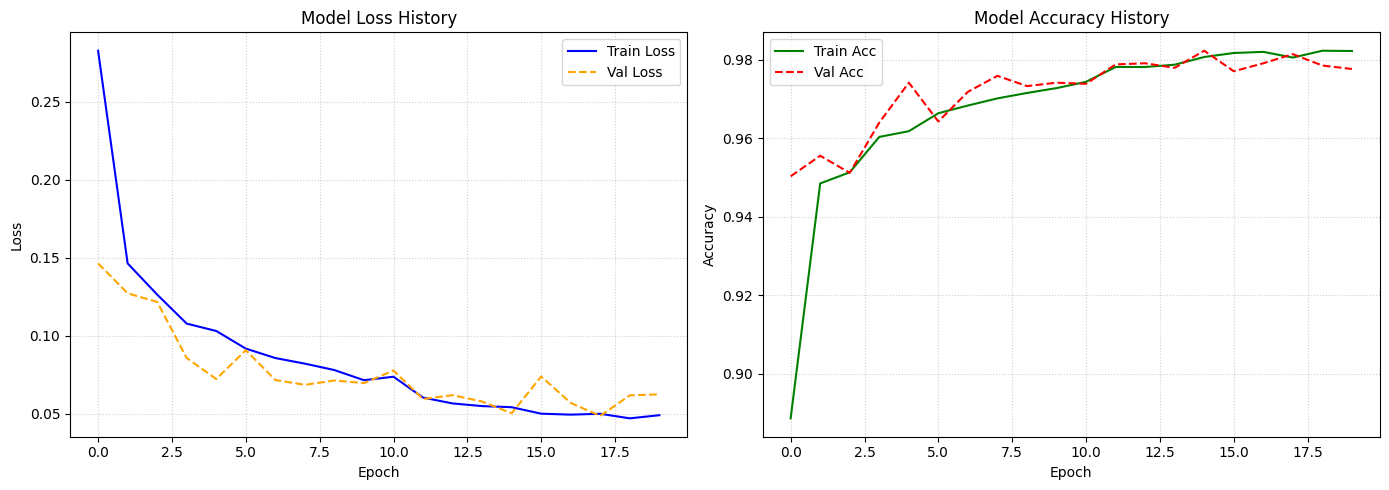

Running evaluation on the validation set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Closed (0)     0.9838    0.9792    0.9815      1732
    Open (1)     0.9790    0.9836    0.9813      1708

    accuracy                         0.9814      3440
   macro avg     0.9814    0.9814    0.9814      3440
weighted avg     0.9814    0.9814    0.9814      3440



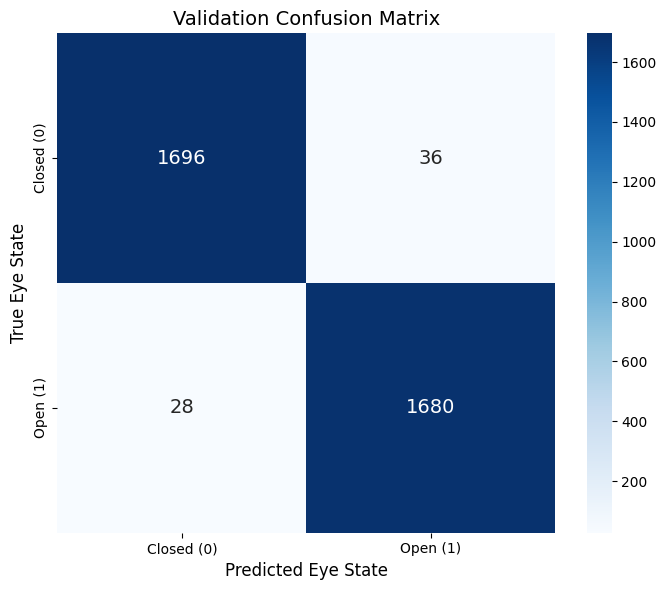

In [ ]:
# ==========================================
# MODEL EVALUATION & REPORT GENERATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch

# 1. Plot Learning Curves (Loss and Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training & Validation Loss
ax1.plot(history['train_loss'], label='Train Loss', color='blue')
ax1.plot(history['val_loss'], label='Val Loss', color='orange', linestyle='--')
ax1.set_title('Model Loss History')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot Training & Validation Accuracy
ax2.plot(history['train_acc'], label='Train Acc', color='green')
ax2.plot(history['val_acc'], label='Val Acc', color='red', linestyle='--')
ax2.set_title('Model Accuracy History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('models/learning_curves.png', dpi=300) # Saves the plot for your report
plt.show()

# 2. Generate Predictions on the Validation Set
print("Running evaluation on the validation set...")
model.eval()
all_preds = []
all_labels = []

# Disable gradient calculation for faster inference
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        # Move tensors to CPU and convert to numpy arrays before appending
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Print the Classification Report
classes = ['Closed (0)', 'Open (1)']
print("\n" + "="*40)
print("CLASSIFICATION REPORT")
print("="*40)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 14}) # Larger font for the numbers
plt.title('Validation Confusion Matrix', fontsize=14)
plt.ylabel('True Eye State', fontsize=12)
plt.xlabel('Predicted Eye State', fontsize=12)

plt.tight_layout()
plt.savefig('models/confusion_matrix.png', dpi=300) # Saves the plot for your report
plt.show()

In [ ]:
from sklearn.metrics import recall_score, balanced_accuracy_score

# 3. Custom Evaluation Metrics: Sensitivity, Specificity, Balanced Accuracy
# recall_score with average=None returns an array of recalls for each class [Class 0, Class 1]
recalls = recall_score(all_labels, all_preds, average=None)

# Class 0 is 'Closed' (Our target event), Class 1 is 'Open'
sensitivity = recalls[0]
specificity = recalls[1]
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n" + "="*45)
print("SAFETY-CRITICAL EVALUATION METRICS")
print("="*45)
print(f"Sensitivity (Closed Eye Detection) : {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity (Open Eye Recognition) : {specificity:.4f} ({specificity*100:.2f}%)")
print("-" * 45)
print(f"Balanced Accuracy                  : {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")
print("="*45)


SAFETY-CRITICAL EVALUATION METRICS
Sensitivity (Closed Eye Detection) : 0.9792 (97.92%)
Specificity (Open Eye Recognition) : 0.9836 (98.36%)
---------------------------------------------
Balanced Accuracy                  : 0.9814 (98.14%)


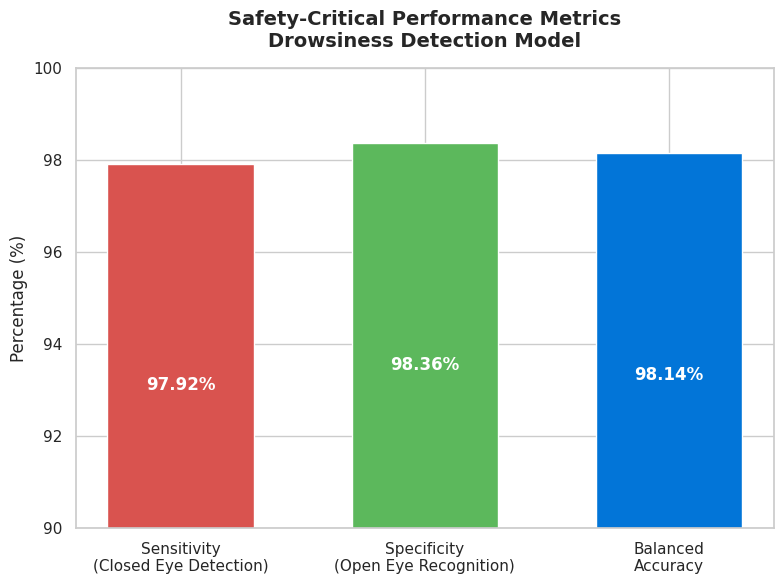

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# The metrics calculated from your model's evaluation
metrics = ['Sensitivity\n(Closed Eye Detection)', 'Specificity\n(Open Eye Recognition)', 'Balanced\nAccuracy']
scores = [97.92, 98.36, 98.14]

# Set up the plot style
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create the bar chart with custom colors
colors = ['#d9534f', '#5cb85c', '#0275d8'] # Red for danger (closed), Green for safe (open), Blue for overall
bars = plt.bar(metrics, scores, color=colors, width=0.6)

# Add the percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 5, f'{yval}%',
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)

# Polish the visual details
plt.ylim(90, 100) # Zoom in on the 90-100% range to highlight the differences
plt.title('Safety-Critical Performance Metrics\nDrowsiness Detection Model', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.tick_params(axis='x', labelsize=11)

# Save and show
plt.tight_layout()
plt.savefig('safety_metrics_bar_chart.png', dpi=300) # Saves a high-res image for your report
plt.show()

In [ ]:
# Install wkhtmltopdf, a dependency for pdfkit to convert HTML to PDF
!sudo apt-get update
!sudo apt-get install wkhtmltopdf

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,934 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,870 kB]
Get:14 http://


DATASET SUMMARY
Total Training Images   : 13759
Total Validation Images : 3440



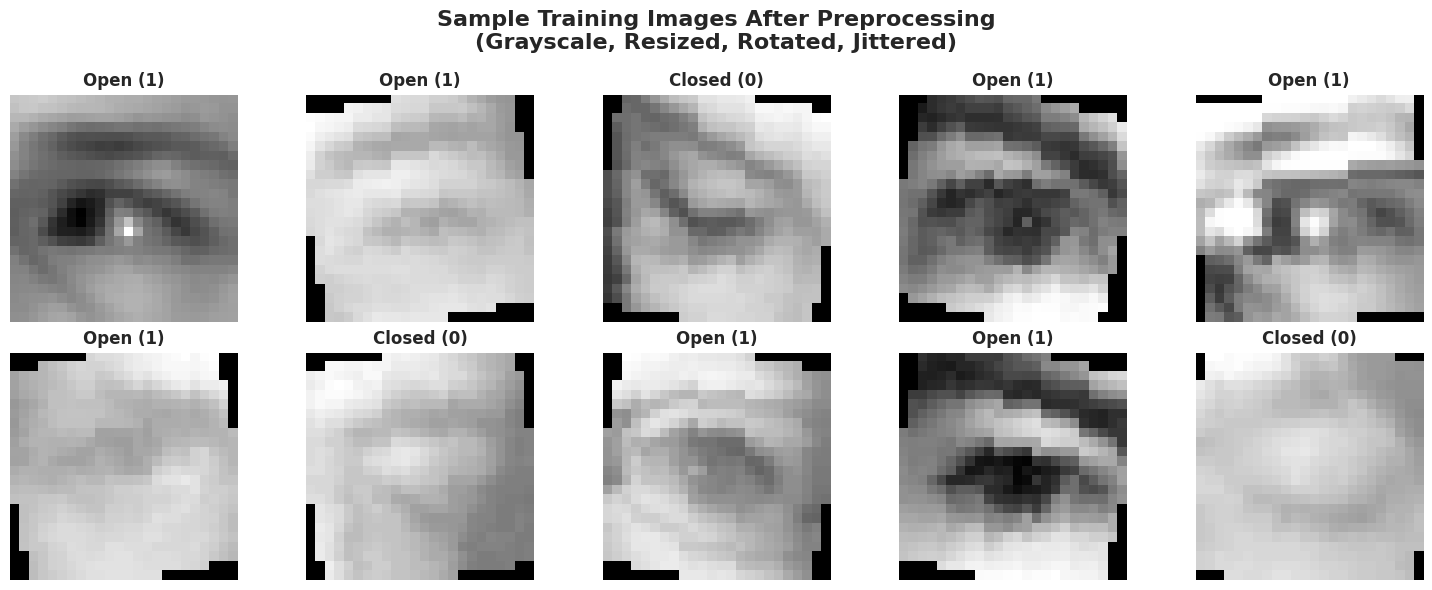

In [ ]:
import torchvision
import numpy as np

# ==========================================
# 1. LOG DATASET SPLITS
# ==========================================
print("\n" + "="*40)
print("DATASET SUMMARY")
print("="*40)
print(f"Total Training Images   : {len(train_dataset)}")
print(f"Total Validation Images : {len(val_dataset)}")
print("="*40 + "\n")

# ==========================================
# 2. VISUALIZE PREPROCESSED IMAGES
# ==========================================
# Grab a single batch of data from the training loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# We only want to show 10 images
images_to_show = images[:10]
labels_to_show = labels[:10]
classes = ['Closed (0)', 'Open (1)']

# Set up the matplotlib figure
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flatten()):
    # 1. Convert tensor to numpy array and reshape from (C, H, W) to (H, W, C)
    img = images_to_show[i].numpy().transpose((1, 2, 0))

    # 2. Un-normalize the image (reverse the mean=0.5, std=0.5 transform)
    img = img * 0.5 + 0.5

    # 3. Squeeze removes the channel dimension since it's 1 for grayscale: (24, 24, 1) -> (24, 24)
    img = img.squeeze()

    # Plot the image
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels_to_show[i]], fontsize=12, fontweight='bold')
    ax.axis('off') # Hide axes for a cleaner look

plt.suptitle('Sample Training Images After Preprocessing\n(Grayscale, Resized, Rotated, Jittered)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('models/preprocessed_samples.png', dpi=300) # Save for your report!
plt.show()

In [ ]:
!pip install pdfkit

import os
import pdfkit
from PyPDF2 import PdfMerger # This import is not used but kept as per original
from google.colab import files, drive

# Mount Google Drive if it's not already mounted
if not os.path.exists('/content/gdrive/MyDrive'):
    drive.mount('/content/gdrive')
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

# Define paths for the source notebook, intermediate HTML, and final PDF
notebook_source_path = '/content/gdrive/MyDrive/AI535/dl_final_project.ipynb'
input_html = '/content/gdrive/MyDrive/AI535/dl_final_project.html'
output_pdf = '/content/gdrive/MyDrive/AI535/dl_final_output.pdf'

# Create the directory if it doesn't exist for the output files
os.makedirs(os.path.dirname(notebook_source_path), exist_ok=True)

print(f"Attempting to convert notebook from: {notebook_source_path}")

# Check if the notebook file exists before attempting conversion
if not os.path.exists(notebook_source_path):
    print(f"ERROR: The notebook file does not exist at '{notebook_source_path}'.")
    print("Please ensure your current notebook is saved to this exact path in Google Drive.")
    print("You might need to go to File -> Save a copy in Drive and specify the path: /content/gdrive/MyDrive/AI535/dl_final_project.ipynb")
else:
    print(f"Notebook found at '{notebook_source_path}'. Proceeding with conversion to HTML.")
    # Convert the notebook to HTML
    # Use --output-dir and --output to explicitly control the output path and filename
    !jupyter nbconvert --to html "{notebook_source_path}" --output-dir "{os.path.dirname(input_html)}" --output "{os.path.basename(input_html)}"

    # Check if the HTML file was successfully created
    if os.path.exists(input_html):
        print(f"HTML file created successfully at: {input_html}")
        # Convert HTML to PDF
        try:
            pdfkit.from_file(input_html, output_pdf)
            print(f"PDF created successfully at: {output_pdf}")
            # Download the generated PDF
            files.download(output_pdf)
        except Exception as e:
            print(f"Error during PDF conversion: {e}")
            print("Please ensure wkhtmltopdf is installed correctly if you encounter issues. Sometimes it requires additional system packages.")
    else:
        print(f"ERROR: HTML file was not created by nbconvert. This might be due to an issue with the conversion or the input .ipynb file.")
        print("Please check the nbconvert output above for any additional error messages.")


ModuleNotFoundError: No module named 'PyPDF2'